In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("Online Retail.xlsx")

print(df.head())
print(df.info())
print(df.isnull().sum())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----

In [2]:
df = df.drop_duplicates()

df = df.dropna(subset=["InvoiceDate"])

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Sales"] = df["Quantity"] * df["UnitPrice"]

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["WeekOfYear"] = df["InvoiceDate"].dt.isocalendar().week.astype(int)

df.to_csv("cleaned_forecast_data.zip",compression="zip", index=False)

print("Cleaned forecast data saved successfully")
print(df.head())

Cleaned forecast data saved successfully
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  Sales  Year  \
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  15.30  2010   
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  2010   
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  22.00  2010   
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  2010   
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  20.34  2010   

   Month  Day  DayOfWeek  WeekOfYear  
0     12    1          2

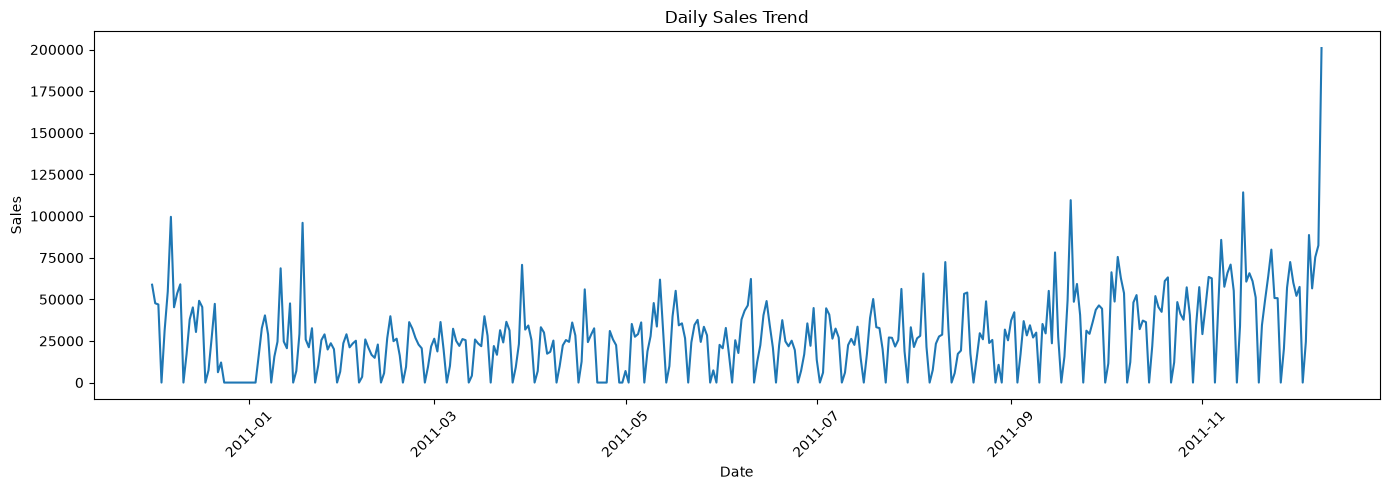

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

daily_sales = (
    df.resample("D", on="InvoiceDate")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_sales, x="InvoiceDate", y="Sales")
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

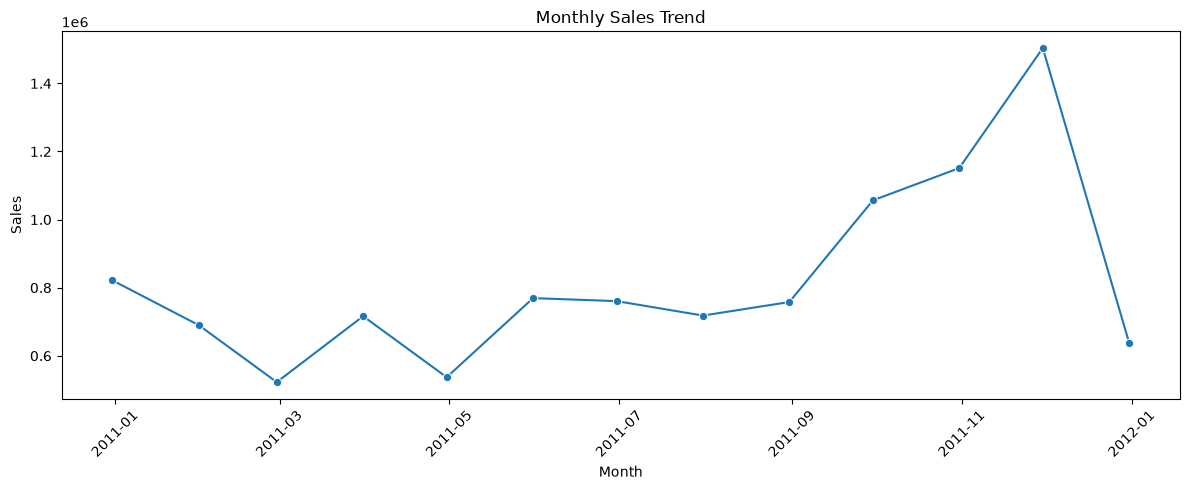

In [4]:
monthly_sales = (
    df.resample("ME", on="InvoiceDate")["Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="InvoiceDate", y="Sales", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

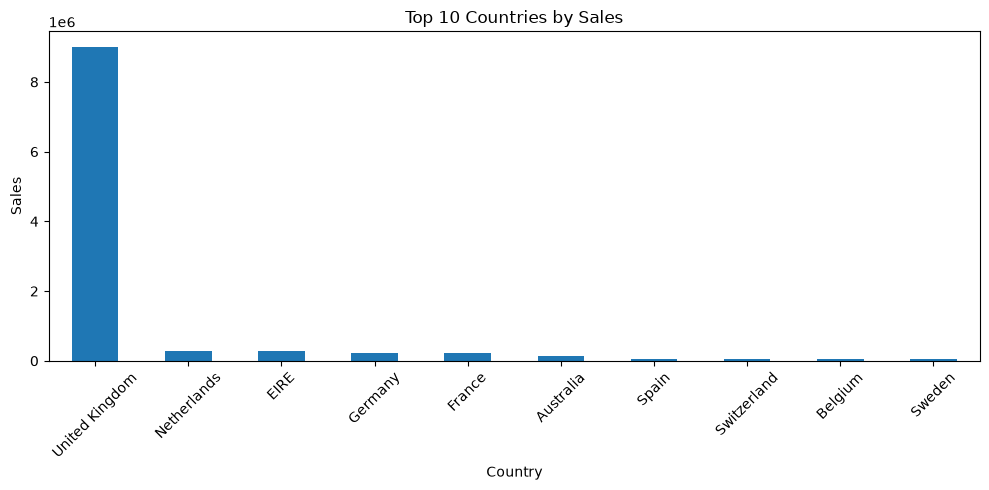

In [5]:
country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

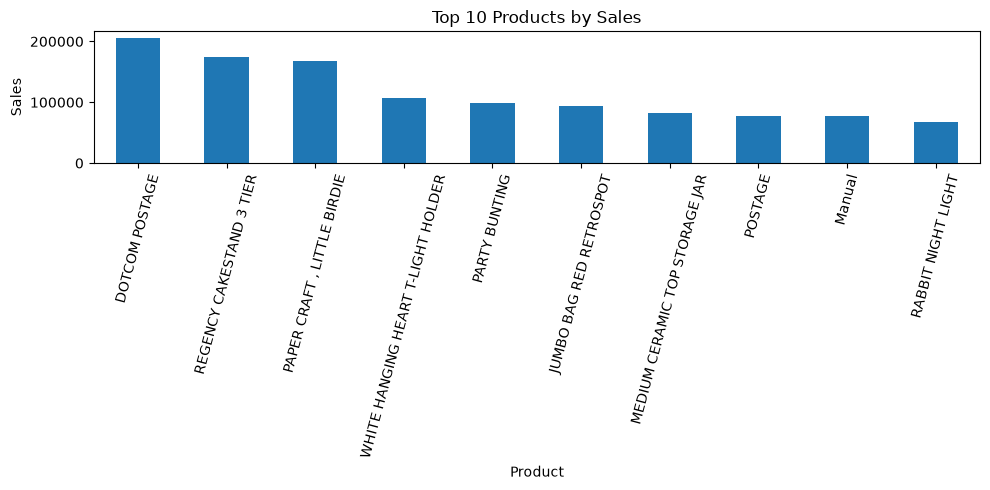

In [6]:
product_sales = (
    df.groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
product_sales.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [7]:
total_sales = df["Sales"].sum()
average_sales = df["Sales"].mean()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
top_country = df.groupby("Country")["Sales"].sum().idxmax()
top_product = df.groupby("Description")["Sales"].sum().idxmax()

print("Total Sales:", total_sales)
print("Average Sales:", average_sales)
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Top Country:", top_country)
print("Top Product:", top_product)

Total Sales: 10642110.804000001
Average Sales: 20.275398862211794
Total Orders: 19960
Total Customers: 4338
Top Country: United Kingdom
Top Product: DOTCOM POSTAGE


In [8]:
forecast_df = (
    df.resample("D", on="InvoiceDate")["Sales"]
    .sum()
    .reset_index()
)

forecast_df["Year"] = forecast_df["InvoiceDate"].dt.year
forecast_df["Month"] = forecast_df["InvoiceDate"].dt.month
forecast_df["Day"] = forecast_df["InvoiceDate"].dt.day
forecast_df["DayOfWeek"] = forecast_df["InvoiceDate"].dt.dayofweek
forecast_df["WeekOfYear"] = forecast_df["InvoiceDate"].dt.isocalendar().week.astype(int)

forecast_df["Lag_1"] = forecast_df["Sales"].shift(1)
forecast_df["Lag_7"] = forecast_df["Sales"].shift(7)
forecast_df["Rolling_7"] = forecast_df["Sales"].rolling(window=7).mean()

forecast_df = forecast_df.dropna()

print(forecast_df.head())

   InvoiceDate     Sales  Year  Month  Day  DayOfWeek  WeekOfYear     Lag_1  \
7   2010-12-08  45235.36  2010     12    8          2          49  99553.85   
8   2010-12-09  53548.19  2010     12    9          3          49  45235.36   
9   2010-12-10  59021.02  2010     12   10          4          49  53548.19   
10  2010-12-11      0.00  2010     12   11          5          49  59021.02   
11  2010-12-12  17125.65  2010     12   12          6          49      0.00   

       Lag_7     Rolling_7  
7   58776.79  46472.291429  
8   47629.42  47317.830000  
9   46898.63  49049.600000  
10      0.00  49049.600000  
11  31364.63  47015.460000  


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

features = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "WeekOfYear",
    "Lag_1",
    "Lag_7",
    "Rolling_7"
]

X = forecast_df[features]
y = forecast_df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 12104.25190891892
RMSE: 22502.41422300802
R2 Score: 0.46313720878995734


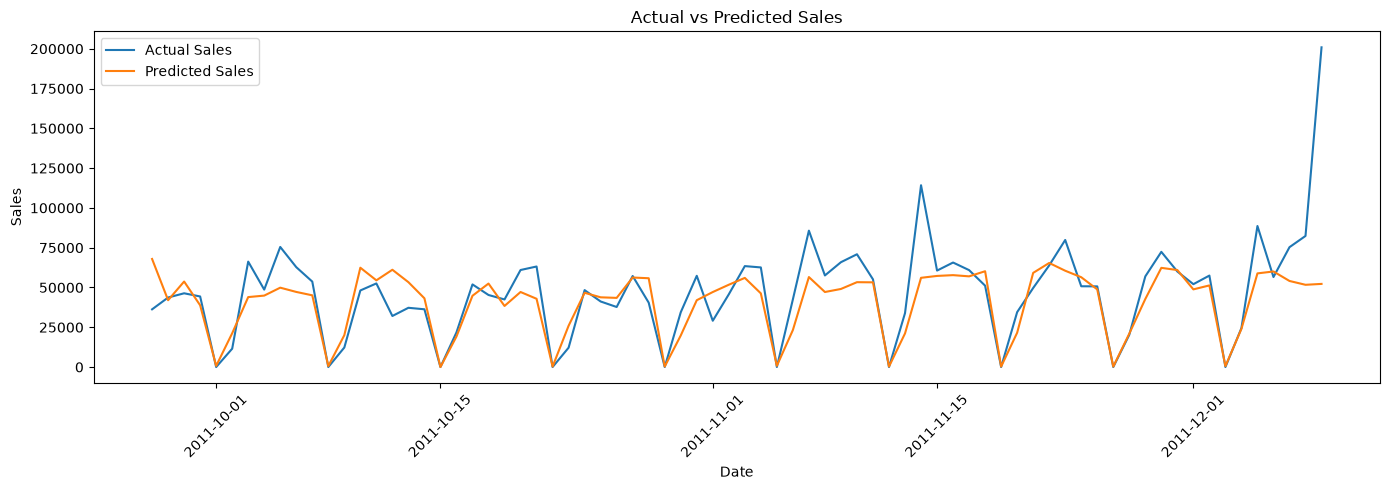

In [13]:
test_dates = forecast_df.loc[y_test.index, "InvoiceDate"].reset_index(drop=True)

results = pd.DataFrame({
    "Date": test_dates,
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred
})

plt.figure(figsize=(14, 5))
plt.plot(results["Date"], results["Actual"], label="Actual Sales")
plt.plot(results["Date"], results["Predicted"], label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
joblib.dump(model, "sales_forecast_model.pkl")

forecast_df.to_csv("forecast_model_data.csv", index=False)

print("Model and forecast data saved successfully")

Model and forecast data saved successfully


In [12]:
last_data = forecast_df.copy()
future_predictions = []

for i in range(7):
    last_date = last_data["InvoiceDate"].max()
    next_date = last_date + pd.Timedelta(days=1)

    lag_1 = last_data.iloc[-1]["Sales"]
    lag_7 = last_data.iloc[-7]["Sales"]
    rolling_7 = last_data.tail(7)["Sales"].mean()

    future_row = pd.DataFrame({
        "Year": [next_date.year],
        "Month": [next_date.month],
        "Day": [next_date.day],
        "DayOfWeek": [next_date.dayofweek],
        "WeekOfYear": [next_date.isocalendar().week],
        "Lag_1": [lag_1],
        "Lag_7": [lag_7],
        "Rolling_7": [rolling_7]
    })

    predicted_sales = model.predict(future_row)[0]

    future_predictions.append({
        "Date": next_date,
        "Predicted_Sales": predicted_sales
    })

    new_row = {
        "InvoiceDate": next_date,
        "Sales": predicted_sales,
        "Year": next_date.year,
        "Month": next_date.month,
        "Day": next_date.day,
        "DayOfWeek": next_date.dayofweek,
        "WeekOfYear": next_date.isocalendar().week,
        "Lag_1": lag_1,
        "Lag_7": lag_7,
        "Rolling_7": rolling_7
    }

    last_data = pd.concat([last_data, pd.DataFrame([new_row])], ignore_index=True)

future_df = pd.DataFrame(future_predictions)

print(future_df)

        Date  Predicted_Sales
0 2011-12-10        288.36590
1 2011-12-11      24200.83737
2 2011-12-12      60403.00594
3 2011-12-13      59083.90703
4 2011-12-14      56318.06361
5 2011-12-15      55140.99731
6 2011-12-16      55107.82811
